<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/year_season.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convert Year/Season → numeric year

Use logistic regression to test whether success probability changes over time

(Optional) Report a point-biserial correlation as a descriptive check

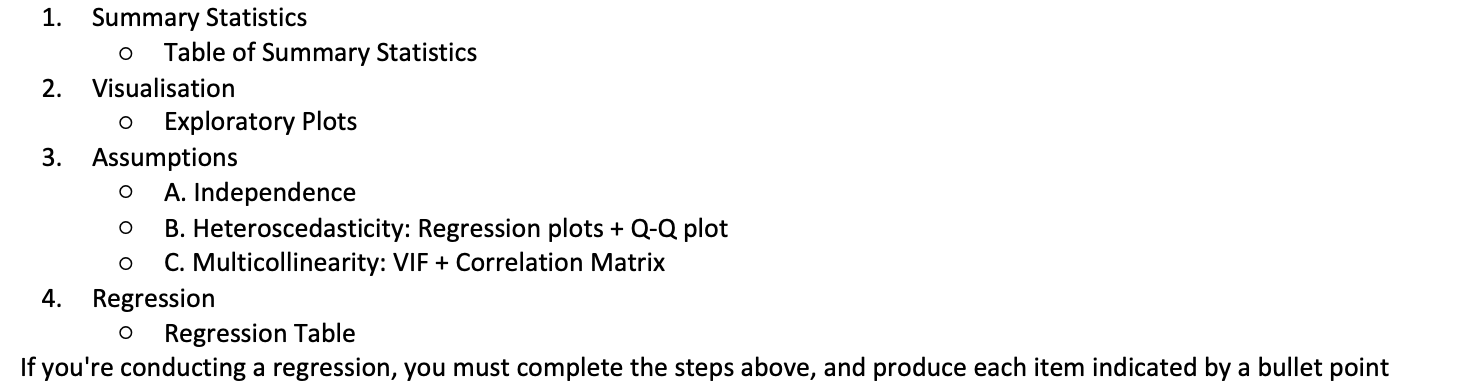

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#same imports as the Week 8 DiD workshop
%matplotlib inline

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pylab
import pandas as pd
import numpy as np

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf

pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.2)
sns.set_style("white")


In [ ]:
df = pd.read_csv( "/content/drive/MyDrive/QM_Grunge_Data/expeditions5.csv")

df.head()



,Yr/Seas,Host,Nationalities,Leader(s),Route(s),Result,Smtrs,Dead,ExpedID,Year,...,hired_DR,mbr_DR,mbr_hired_ratio,total_DR,clean_routes,route_codes,result_clean,result_code,grp_success,success_rate
0,1990 Spr,China,"USA, China, USSR","Jim Whittaker, Vladimir Shataev, Lobsang Dawa",N Col-NE Ridge,Success,20.0,NaN,EVER-901-03,1990,...,0.0,0.0,0.00,0.0,n col-ne ridge,2,success,1,1,0.512820513
1,1990 Spr,Nepal,Nepal,Chetra Bahadur Gurung,S Col-SE Ridge,Success,4.0,NaN,EVER-901-04,1990,...,0.0,0.0,0.08,0.0,s col-se ridge,1,success,1,1,0.142857143
2,1990 Spr,Nepal,Australia,Timothy Macartney-Snape,Lho La-W Ridge (to 7400m) / S Col-SE Ridge,Success,1.0,NaN,EVER-901-06,1990,...,0.0,0.0,0.00,0.0,lho la-w ridge,6,success,1,1,0.25
3,1990 Spr,Nepal,USA,Glenn Porzak,S Col-SE Ridge,Success,9.0,NaN,EVER-901-07,1990,...,0.0,0.0,0.30,0.0,s col-se ridge,1,success,1,1,0.692307692
4,1990 Spr,Nepal,"New Zealand, Belgium, Canada, Sweden, USA",Rob Hall,S Col-SE Ridge,Success,7.0,NaN,EVER-901-08,1990,...,0.0,0.0,0.10,0.0,s col-se ridge,1,success,1,1,0.636363636


In [ ]:
print(df.columns)
print(df.shape)


Index(['Yr/Seas', 'Host', 'Nationalities', 'Leader(s)', 'Route(s)', 'Result',
       'Smtrs', 'Dead', 'ExpedID', 'Year', 'expedition_code', 'group_size',
       'total_members', 'death_mbrs', 'hired_deaths', 'hired_count',
       'hired_DR', 'mbr_DR', 'mbr_hired_ratio', 'total_DR', 'clean_routes',
       'route_codes', 'result_clean', 'result_code', 'grp_success',
       'success_rate'],
      dtype='object')
(2192, 26)


In [ ]:
# keep only the columns we need and drop missing values
df = df[["Yr/Seas", "success_rate"]].dropna().copy()

# extract the numeric year from "Yr/Seas" (e.g. "2019 Spring" → 2019)
df["Year"] = (
    df["Yr/Seas"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

# ensure success_rate is numeric and binary (0 or 1 only)
df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")
df = df[df["success_rate"].isin([0, 1])]

In [ ]:
#Step 1: Summary statistics
summary = df[["success_rate", "Year"]].describe().round(3).T
summary[["count", "mean", "std", "min", "max"]]

,count,mean,std,min,max
success_rate,1136.0,0.367,0.482,0.0,1.0
Year,1136.0,2008.718,8.241,1990.0,2025.0


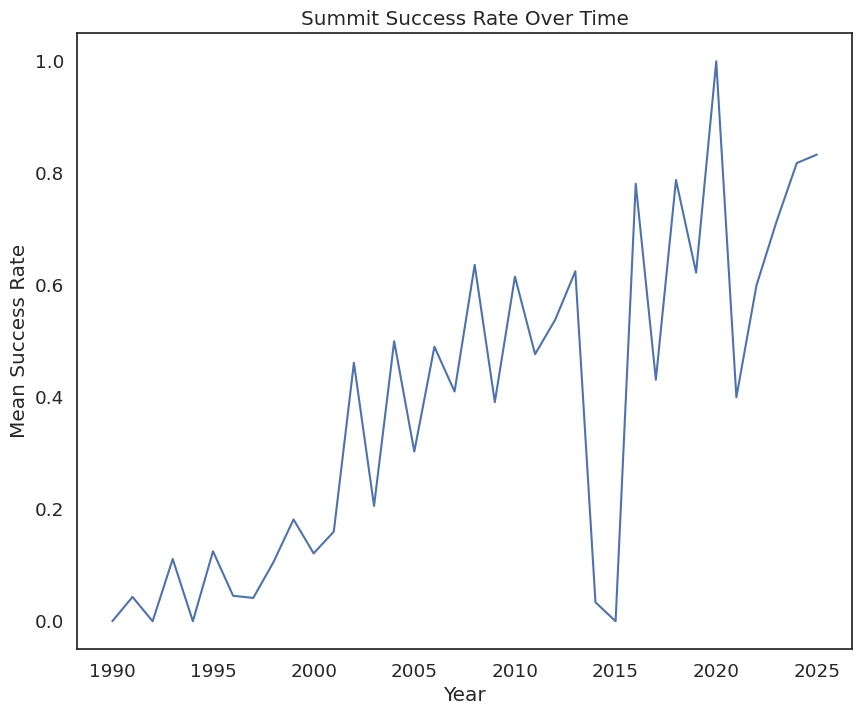

In [ ]:
#Step 2: Visualisation

#(A)Success Rate Over Time
yearly_success = df.groupby("Year")["success_rate"].mean().reset_index()

plt.figure()
plt.plot(yearly_success["Year"], yearly_success["success_rate"])
plt.xlabel("Year")
plt.ylabel("Mean Success Rate")
plt.title("Summit Success Rate Over Time")
plt.show()


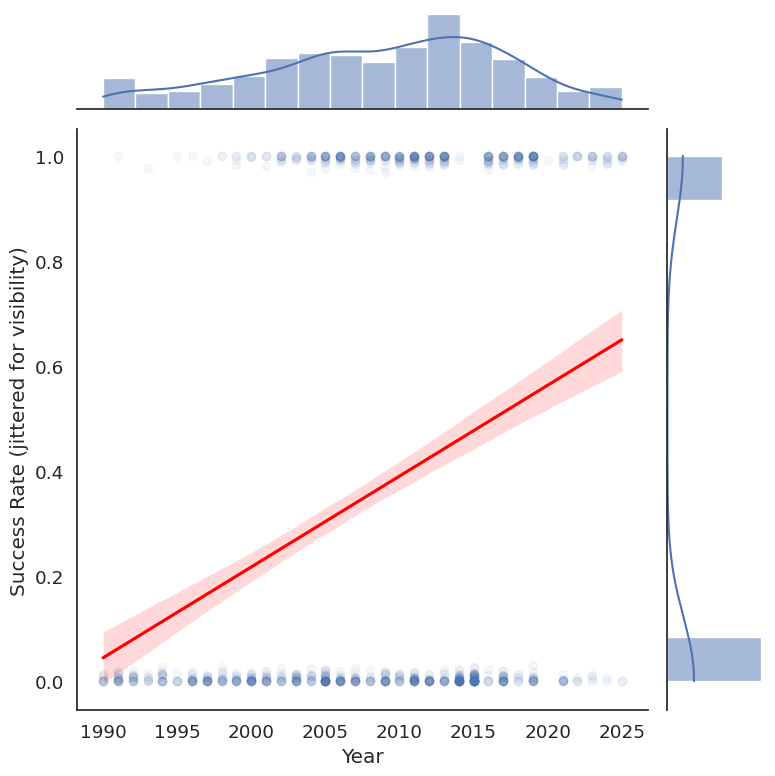

In [ ]:
#(B)Jointplot

# keep only what you need (add Smtrs and group_size if you have them)
df = df[["Yr/Seas", "success_rate"]].copy()

# year from Yr/Seas
df["Year"] = df["Yr/Seas"].str.extract(r"(\d{4})").astype(int)

# success_rate to numeric
df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")

# drop missing
df = df.dropna(subset=["Year", "success_rate"]).copy()

# success_rate should be a proportion, so keep sensible values
# (if your calculation occasionally produces >1 due to data issues, drop those rows)
df = df[(df["success_rate"] >= 0) & (df["success_rate"] <= 1)].copy()



import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df.copy()
df_plot["success_rate_jitter"] = np.clip(
    df_plot["success_rate"] + np.random.normal(0, 0.01, size=len(df_plot)),
    0, 1
)

sns.jointplot(
    data=df_plot,
    x="Year",
    y="success_rate_jitter",
    kind="reg",
    scatter_kws=dict(alpha=0.05),
    line_kws=dict(color="red"),
    height=8
)

plt.xlabel("Year")
plt.ylabel("Success Rate (jittered for visibility)")
plt.show()




The apparent polarisation in the joint plot reflects the discrete nature of expedition-level success rates and heavy overplotting at boundary values (0 and 1), rather than an absence of intermediate outcomes.

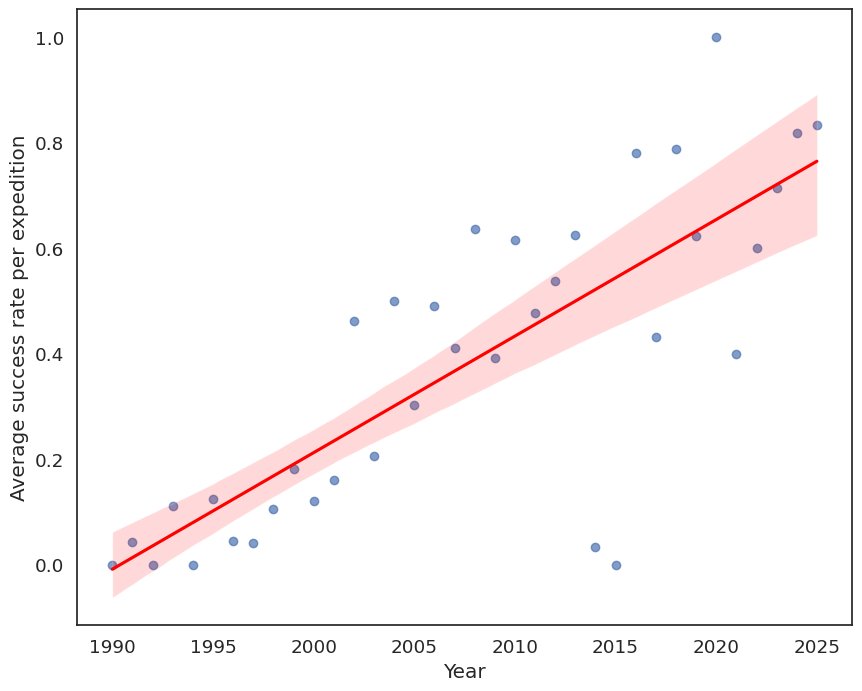

In [ ]:
yearly = df.groupby("Year")["success_rate"].mean().reset_index()

sns.regplot(
    data=yearly,
    x="Year",
    y="success_rate",
    scatter_kws=dict(alpha=0.7),
    line_kws=dict(color="red")
)

plt.ylabel("Average success rate per expedition")
plt.show()


In [ ]:
#Step 3: Assumptions
#(A)Independence
print("Independence assumption: discuss whether observations are independent (e.g., climbers within same expedition may be correlated).")

#(B)Heteroscedasticity + Q-Q Plot
#Logistic regression does not assume homoscedastic errors. The variance of the dependent variable depends on the predicted probability and therefore varies across observations by design.
#Maybe need a better academic justification for this


Independence assumption: discuss whether observations are independent (e.g., climbers within same expedition may be correlated).


In [ ]:
#Multicollinearity
# extract Year
df["Year"] = df["Yr/Seas"].astype(str).str.extract(r"(\d{4})").astype(int)

# extract Season explicitly (only valid values)
df["season"] = df["Yr/Seas"].astype(str).str.extract(r"(Spr|Aut|Win)", expand=False)

# sanity check
df[["Yr/Seas", "Year", "season"]].head()


season_dummies = pd.get_dummies(
    df["season"],
    prefix="season",
    drop_first=True  # IMPORTANT
).astype(int)

X_mc = pd.concat(
    [df[["Year"]], season_dummies],
    axis=1
)

X_mc.head()


,Year,season_Spr,season_Win
18,1991,1,0
51,1993,1,0
81,1995,1,0
92,1996,1,0
112,1997,1,0


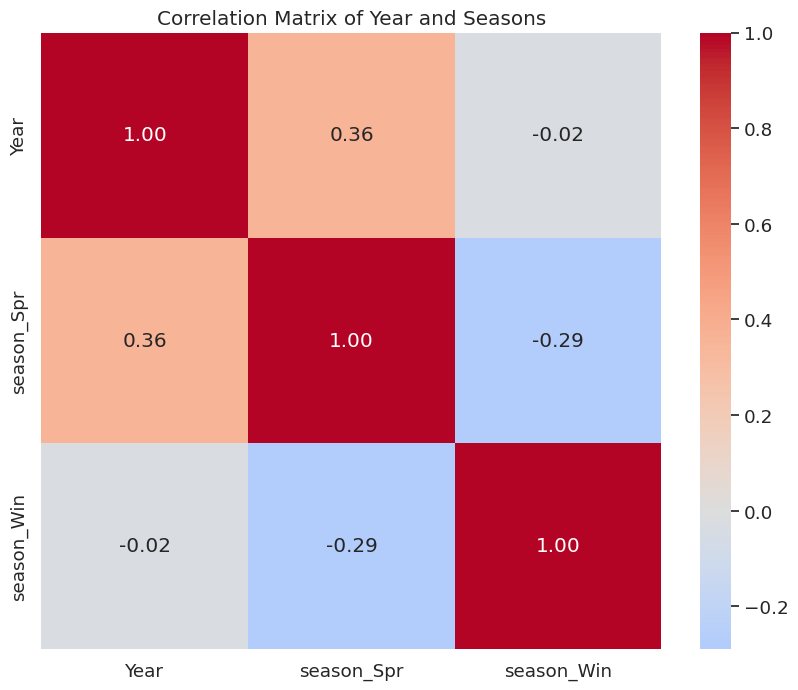

In [ ]:
#Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(
    X_mc.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Year and Seasons")
plt.show()

In [ ]:
#VIF (Variance Inflation Factor)

#VIF tells you how much a predictor’s variance is inflated because it is correlated with other predictors.

#If VIF = 1 → no correlation with other predictors → no inflation.
#If VIF = 5 → the variance of this coefficient is 5× bigger than it would be if this predictor were alone.
#If VIF = 10 → serious multicollinearity.

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

def drop_column_using_vif_(df, list_var_not_to_remove=None, thresh=5):
    while True:
        df_with_const = add_constant(df)

        vif_df = pd.Series(
            [variance_inflation_factor(df_with_const.values, i)
             for i in range(df_with_const.shape[1])],
            name="VIF",
            index=df_with_const.columns
        ).to_frame()

        vif_df = vif_df.drop("const")

        if list_var_not_to_remove is not None:
            vif_df = vif_df.drop(list_var_not_to_remove, errors="ignore")

        print("Max VIF:", vif_df.VIF.max())

        if vif_df.VIF.max() > thresh:
            index_to_drop = vif_df.index[vif_df.VIF == vif_df.VIF.max()].tolist()[0]
            print("Dropping:", index_to_drop)
            df = df.drop(columns=index_to_drop)
        else:
            break

    return df


In [ ]:
season_cols = season_dummies.columns.tolist()

vif_selected = drop_column_using_vif_(
    X_mc,
    list_var_not_to_remove=season_cols,  # protect the whole season dummy set
    thresh=5
)

print("Columns remaining after VIF selection:")
print(vif_selected.columns)

Max VIF: 1.1591145558342524
Columns remaining after VIF selection:
Index(['Year', 'season_Spr', 'season_Win'], dtype='object')


In [ ]:
#Step 4: OLS Regression

In [ ]:
import statsmodels.formula.api as smf

df = pd.read_csv("/content/drive/MyDrive/QM_Grunge_Data/expeditions5.csv")

# keep only what we need
df = df[["Yr/Seas", "success_rate"]].copy()

# make success_rate numeric
df["success_rate"] = pd.to_numeric(df["success_rate"], errors="coerce")


In [ ]:
# Year from Yr/Seas (e.g. "1990 Spr" -> 1990)
df["Year"] = df["Yr/Seas"].astype(str).str.extract(r"(\d{4})").astype(float)

# Season from Yr/Seas (only keeps Spr/Aut/Win)
df["season"] = df["Yr/Seas"].astype(str).str.extract(r"(Spr|Aut|Win)", expand=False)


In [ ]:
df = df.dropna(subset=["success_rate", "Year", "season"]).copy()

# If success_rate is a rate, it should be between 0 and 1
df = df[(df["success_rate"] >= 0) & (df["success_rate"] <= 1)].copy()

# make Year integer now that it’s clean
df["Year"] = df["Year"].astype(int)


In [ ]:
ols_model = smf.ols("success_rate ~ Year + C(season)", data=df).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:           success_rate   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     126.0
Date:                Wed, 07 Jan 2026   Prob (F-statistic):           3.04e-75
Time:                        22:44:29   Log-Likelihood:                -924.15
No. Observations:                2171   AIC:                             1856.
Df Residuals:                    2167   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -25.4023      1.930  

In [ ]:
print(df["success_rate"].describe())
print(df["success_rate"].value_counts().head(10))
print(df["season"].value_counts())



count    2171.000000
mean        0.494270
std         0.401471
min         0.000000
25%         0.000000
50%         0.571429
75%         0.879394
max         1.000000
Name: success_rate, dtype: float64
success_rate
0.000000    709
1.000000    417
0.666667     84
0.500000     82
0.750000     50
0.800000     38
0.333333     27
0.857143     25
0.250000     24
0.833333     23
Name: count, dtype: int64
season
Spr    2007
Aut     150
Win      14
Name: count, dtype: int64
